In [132]:
import numpy as np
import torch
import matplotlib.pyplot as plt

In [142]:
class Distribution_and_sample:
    def __init__(self, distribution, sample):
        # Distribution attributes
        self.distribution = distribution
        self.ncases = distribution.shape[0]
        self.true_mean = np.mean(distribution)

        # Sample attributes
        self.sample = sample
        self.nsamples = sample.shape[0]

    def get_crps1(self):
        v1 = self.distribution
        v2 = self.sample
        return np.abs(v1 [:, None] - v2[None, :])

    def get_crps2(self):
        v = self.sample
        return np.abs(v[:, None] - v[None, :])

    def get_crps1_total(self):
        return 1 / (self.nsamples * self.ncases) * np.sum(self.get_crps1())

    def get_crps2_total(self):
        return 1 / ( 2 * (self.nsamples**2) ) * np.sum(self.get_crps2())

    def get_crps_total(self):
        return 1 / (self.nsamples  * self.ncases) * np.sum(self.get_crps1()) - 1 / ( 2 * (self.nsamples**2) ) * np.sum(self.get_crps2())

    def get_fcrps_total(self):
        return 1 / (self.nsamples  * self.ncases) * np.sum(self.get_crps1()) - 1 / ( 2 * (self.nsamples* (self.nsamples-1)) ) * np.sum(self.get_crps2())

    def plot_histograms(self, bins=10, density=False, figsize=(8, 5), return_hist=False):
        """
        Draw histograms of distribution and sample, and annotate CRPS totals on the figure.
        Returns (fig, ax, (hist_dist, edges_dist, hist_samp, edges_samp)) if return_hist=True.
        """
      
        # compute histograms
        hist_dist, edges_dist = np.histogram(self.distribution, bins=bins, density=density)
        hist_samp, edges_samp = np.histogram(self.sample, bins=bins, density=density)

        # scores
        c1 = self.get_crps1_total()
        c2 = self.get_crps2_total()
        c  = self.get_crps_total()

        # plot
        fig, ax = plt.subplots(figsize=figsize)
        ax.hist(self.distribution, bins=bins, density=density, alpha=0.5, label="distribution")
        ax.hist(self.sample,       bins=bins, density=density, alpha=0.5, label="sample")

        ax.set_xlabel("value")
        ax.set_ylabel("density" if density else "count")
        ax.legend(loc="best")

        # annotate scores on the image
        text = (f"CRPS1_total = {c1:.6f}\n"
                f"CRPS2_total = {c2:.6f}\n"
                f"CRPS_total  = {c:.6f}")
        ax.text(0.98, 0.98, text, ha="right", va="bottom",
                transform=ax.transAxes,
                bbox=dict(boxstyle="round", fc="white", ec="0.5"))

        fig.tight_layout()

        if return_hist:
            return fig, ax, (hist_dist, edges_dist, hist_samp, edges_samp)
        return fig, ax


(<Figure size 800x500 with 1 Axes>, <Axes: xlabel='value', ylabel='count'>)

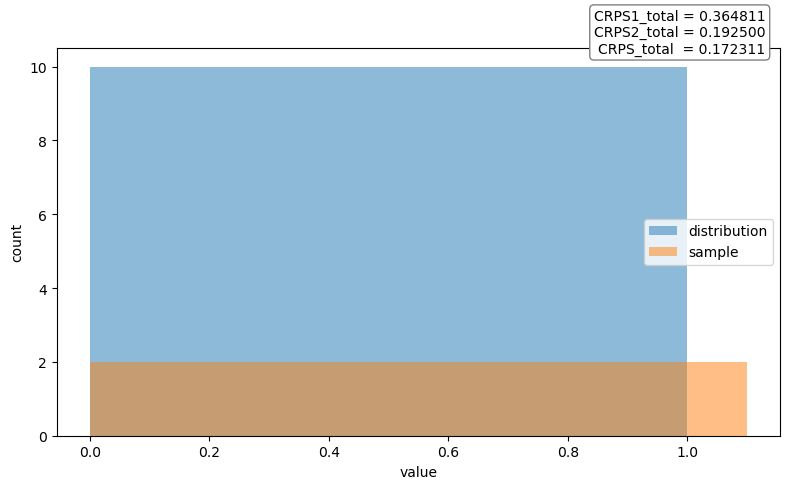

In [143]:
simple_linear_distribution = Distribution_and_sample(np.linspace(0, 1, 100), np.linspace(0, 1.1, 20))

simple_linear_distribution.get_crps1_total()

simple_linear_distribution.plot_histograms()

In [135]:
simple_linear_distribution = Distribution_and_sample(np.linspace(0, 1, 100), np.linspace(0, 1.1, 20))

print(simple_linear_distribution.get_crps1_total(), simple_linear_distribution.get_crps2_total(), simple_linear_distribution.get_crps_total(), simple_linear_distribution.get_fcrps_total())

simple_linear_distribution2 = Distribution_and_sample(np.linspace(0, 1, 100), np.linspace(0, 1, 100))

print(simple_linear_distribution2.get_crps1_total(), simple_linear_distribution2.get_crps2_total(), simple_linear_distribution2.get_crps_total(), simple_linear_distribution2.get_fcrps_total())

simple_linear_distribution3 = Distribution_and_sample(np.linspace(0, 1, 100), 0.5 * np.ones(100))

print(simple_linear_distribution3.get_crps1_total(), simple_linear_distribution3.get_crps2_total(), simple_linear_distribution3.get_crps_total(), simple_linear_distribution3.get_fcrps_total())

simple_linear_distribution4 = Distribution_and_sample(np.linspace(0, 1, 100), np.linspace(-0.5, 1.5, 100))

print(simple_linear_distribution4.get_crps1_total(), simple_linear_distribution4.get_crps2_total(), simple_linear_distribution4.get_crps_total(), simple_linear_distribution4.get_fcrps_total())

0.36481111111111114 0.1925 0.17231111111111114 0.16217953216374273
0.3366666666666667 0.16833333333333336 0.16833333333333336 0.1666329966329967
0.2525252525252526 0.0 0.2525252525252526 0.2525252525252526
0.5471212121212122 0.3366666666666667 0.2104545454545455 0.20705387205387216


In [123]:
simple_linear_distribution.true_mean

np.float64(0.5)